# Simple HTG Algebra


An HTG is a hierarchal tensor graph object used to encode a CREST model. 

When using a tensor graph representation, the operations performed by the model's layers, such as matrix multiplications and element-wise operations, are depicted as nodes in the tensor graph. The flow of data through the layers, represented by tensors, corresponds to the edges in the tensor graph.

In [1]:
#change crest import to appropriate location
%cd -q ..
from crest import HierarchalTensorGraph
from math import exp

/Users/draghun1/miniconda3/envs/crest_cpu/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/draghun1/miniconda3/envs/crest_cpu/lib/python3.10/site-packages/tensorflow/python/keras/engine/training_arrays_v1.py:37: UserWarning: A NumPy version >=1.22.4 and <1.29.0 is required for this version of SciPy (detected version 1.22.3)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


#### Simple HTG basenodes for addition and multiplication

In [2]:
class Add(HierarchalTensorGraph):
    def __init__(self,name):
        self.name = name
        
        #call the basenode constructor
        super().__init__(lambda X : {'sum' :  X['x_1'] + X['x_2']},
                         name=name,
                         inputs={'x_1' : None, 'x_2' : None},
                         outputs={'sum' : None}
                        )
        
class Multiply(HierarchalTensorGraph):
    def __init__(self,name):
        self.name = name
        
        #call the basenode constructor
        super().__init__(lambda X : {'product' : X['scalar']*X['x']},
                         name=name,
                         inputs={'scalar' : None, 'x' : None},
                         outputs={'product' : None}
                        )

#### A Coupled HTG that to perform a*(b+c)

In [3]:
class AddMult(HierarchalTensorGraph):
    """Crest HTG to add and multiply a number"""

    def __init__(self, name):
        super().__init__(name=name,
                         inputs={'scalar': None, 'x_1': None, 'x_2': None},
                         outputs={'add_mult': None},
                         edges=[('input', Add('adder')), ('input', Multiply(
                             'multiplier')), ('adder', 'multiplier'), ('multiplier', 'output')]
                         )

        # renaming of keys
        self.rename_io(inputs_map={'sum': 'x'}, outputs_map={
                       'product': 'add_mult'}, node='multiplier')

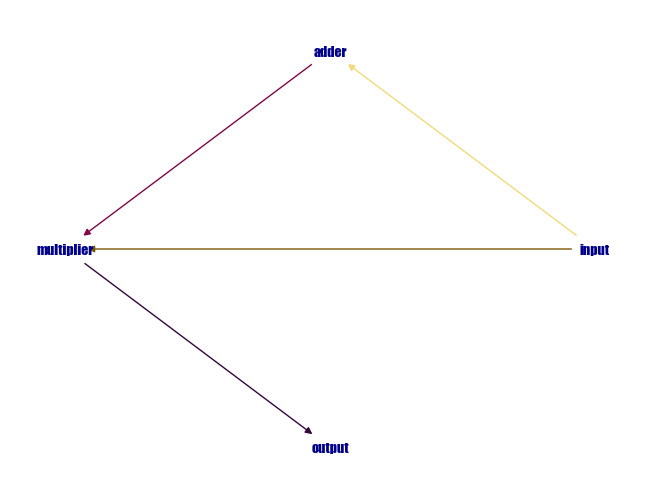

In [4]:
#create instance
import numpy as np 

add_mult = AddMult('add_mult')
add_mult.draw()


In [5]:
X = {'x_1' : 0.8, 'x_2' : 1.2, 'scalar' : 1.3}
add_mult(X)

{'add_mult': 2.6}

#### A HTG that combines for exp(a*(b+c))

In [6]:
class Exp(HierarchalTensorGraph):
    def __init__(self,name):
        self.name = name
        
        #call the basenode constructor
        super().__init__(lambda X : {'exp' : exp(X['x'])},
                         name=name,
                         inputs={'x' : None},
                         outputs={'exp' : None}
                        )
class AddMultExp(HierarchalTensorGraph):
    
    def __init__(self):
        super().__init__(name='add_mult_exp',
                         inputs = {'x_1' : None, 'x_2' : None, 'scalar' : None},
                         outputs = {'add_mult_exp' : None},
                         edges=[('input',AddMult('add_mult')), ('add_mult',Exp('exponentiate')), ('exponentiate','output')]
                        )
        
        #define graph model
        self.rename_io(inputs_map={'add_mult':'x'},outputs_map={'exp':'add_mult_exp'},node='exponentiate')
        

In [7]:
add_mult_exp = AddMultExp()
add_mult_exp.print_edge_labels()

,source,target,source output,target inputs,valid
0,input,add_mult,"['x_1', 'scalar', 'x_2']","['x_1', 'scalar', 'x_2']",True
1,add_mult,exponentiate,['x'],['x'],True
2,exponentiate,output,['add_mult_exp'],['add_mult_exp'],True


In [8]:
print(add_mult_exp(X))
add_mult_exp.print_edge_labels()

{'add_mult_exp': 13.463738035001692}


,source,target,source output,target inputs,valid
0,input,add_mult,"['x_1', 'scalar', 'x_2']","['x_1', 'scalar', 'x_2']",True
1,add_mult,exponentiate,['x'],['x'],True
2,exponentiate,output,['add_mult_exp'],['add_mult_exp'],True


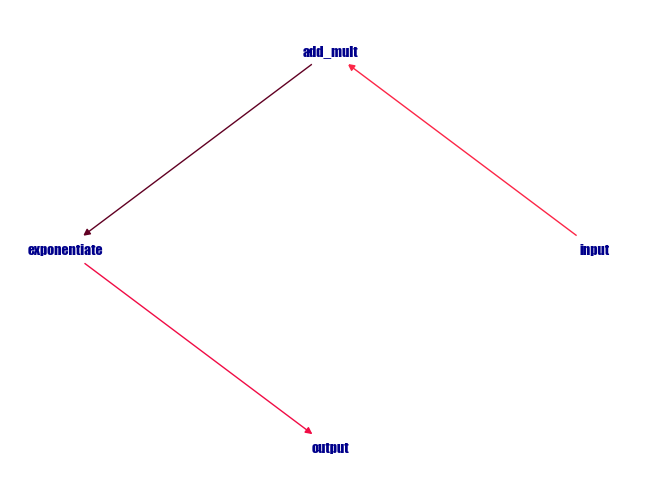

In [9]:
#draw the graph
add_mult_exp.draw()

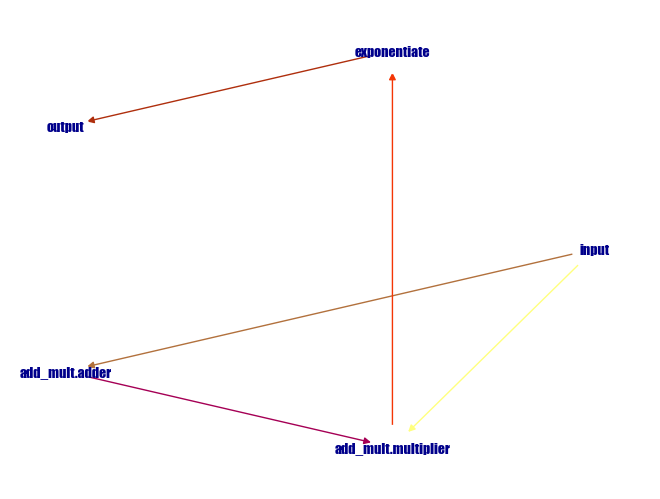

In [10]:
#draw the graph with add_mult expanded
add_mult_exp.draw(expand_nodes='add_mult')

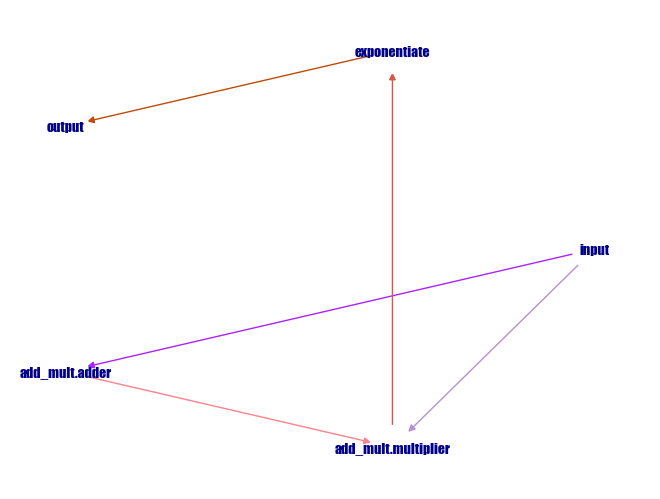

In [11]:
#draw the graph with everything expanded
add_mult_exp.draw(expand_nodes='all')

In [12]:
add_mult_exp.print_edge_labels(expand_nodes='all')

,source,target,source output,target inputs,valid
0,input,add_mult.adder,"['x_1', 'scalar', 'x_2']","['x_1', 'x_2']",True
1,input,add_mult.multiplier,"['x_1', 'scalar', 'x_2']","['x', 'scalar']",True
2,exponentiate,output,['add_mult_exp'],['add_mult_exp'],True
3,add_mult.adder,add_mult.multiplier,['x'],"['x', 'scalar']",True
4,add_mult.multiplier,exponentiate,['x'],['x'],True


In [13]:
add_mult.print_edge_labels()

,source,target,source output,target inputs,valid
0,input,adder,"['x_1', 'scalar', 'x_2']","['x_1', 'x_2']",True
1,input,multiplier,"['x_1', 'scalar', 'x_2']","['x', 'scalar']",True
2,adder,multiplier,['x'],"['x', 'scalar']",True
3,multiplier,output,['add_mult'],['add_mult'],True
